In [1]:
import tensorflow as tf

In [2]:
input_var = tf.Variable(initial_value=3.0)

In [3]:
input_var

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0>

In [4]:
with tf.GradientTape() as tape:
    result = tf.square(input_var)
    print(result)

gradient = tape.gradient(result, input_var)

tf.Tensor(9.0, shape=(), dtype=float32)


In [5]:
gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

In [6]:
time = tf.Variable(6.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
accelaration = outer_tape.gradient(speed, time)

In [7]:
accelaration

<tf.Tensor: shape=(), dtype=float32, numpy=9.800000190734863>

In [8]:
speed

<tf.Tensor: shape=(), dtype=float32, numpy=58.80000305175781>

## linear classifier from scratch

In [9]:
import numpy as np
import matplotlib.pyplot as plt


In [184]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.3], [0.3, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.3], [0.3, 1]], size=num_samples_per_class
)
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [185]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        # np.ones((num_samples_per_class, 1), dtype="float32"),
        np.full((num_samples_per_class, 1), 2, dtype="float32"),
    )
    
)

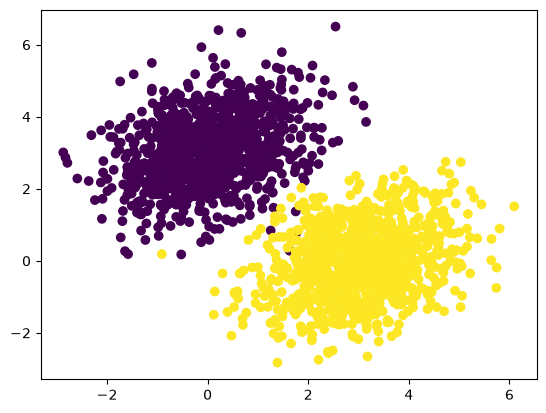

In [186]:
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [199]:
input_dim = 2
output_dim = 1
w = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))


In [188]:
w

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[0.8128331],
       [0.1573168]], dtype=float32)>

In [189]:
b

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>

In [190]:
def model(inputs, w, b):
    return tf.matmul(inputs, w) + b

In [200]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [201]:
learning_rate = 0.15

# @tf.function(jit_compile=True)
def training_step(inputs, targets, w, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs=inputs, w=w, b=b)
        loss = mean_squared_error(targets=targets, predictions=predictions)
        
    grad_loss_wrt_w, grad_loss_wrt_b = tape.gradient(loss, [w, b])
    w.assign_sub(grad_loss_wrt_w*learning_rate)
    b.assign_sub(grad_loss_wrt_b*learning_rate)
    return loss

In [202]:
for step in range(40):
    loss = training_step(inputs=inputs, targets=targets, w=w, b=b)
    print(f"loss at step {step}: {loss:.4F}")

loss at step 0: 4.0388
loss at step 1: 2.9894
loss at step 2: 2.6405
loss at step 3: 2.5294
loss at step 4: 2.5005
loss at step 5: 2.5010
loss at step 6: 2.5131
loss at step 7: 2.5307
loss at step 8: 2.5517
loss at step 9: 2.5750
loss at step 10: 2.6005
loss at step 11: 2.6278
loss at step 12: 2.6568
loss at step 13: 2.6873
loss at step 14: 2.7194
loss at step 15: 2.7528
loss at step 16: 2.7876
loss at step 17: 2.8236
loss at step 18: 2.8609
loss at step 19: 2.8992
loss at step 20: 2.9387
loss at step 21: 2.9793
loss at step 22: 3.0209
loss at step 23: 3.0635
loss at step 24: 3.1071
loss at step 25: 3.1517
loss at step 26: 3.1972
loss at step 27: 3.2437
loss at step 28: 3.2911
loss at step 29: 3.3395
loss at step 30: 3.3887
loss at step 31: 3.4389
loss at step 32: 3.4900
loss at step 33: 3.5420
loss at step 34: 3.5950
loss at step 35: 3.6489
loss at step 36: 3.7037
loss at step 37: 3.7594
loss at step 38: 3.8161
loss at step 39: 3.8737


In [168]:
predictions = model(inputs, w, b)

In [171]:
predictions

<tf.Tensor: shape=(2000, 1), dtype=float32, numpy=
array([[0.05302721],
       [0.05525216],
       [0.23104654],
       ...,
       [1.0950015 ],
       [1.2063762 ],
       [0.82212824]], shape=(2000, 1), dtype=float32)>

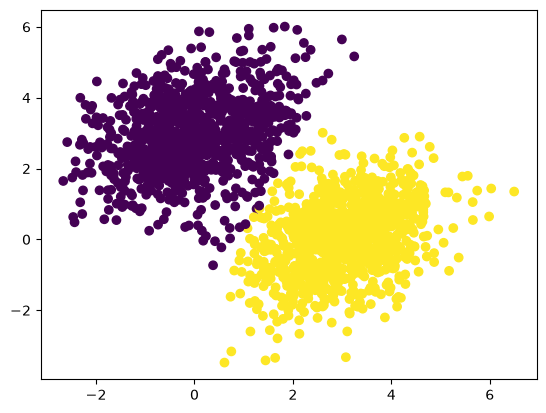

In [172]:
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

In [173]:
predictions[:, 0]> 0.5

<tf.Tensor: shape=(2000,), dtype=bool, numpy=array([False, False, False, ...,  True,  True,  True], shape=(2000,))>

In [174]:
x = np.linspace(-1, 4, 100)
x

array([-1.        , -0.94949495, -0.8989899 , -0.84848485, -0.7979798 ,
       -0.74747475, -0.6969697 , -0.64646465, -0.5959596 , -0.54545455,
       -0.49494949, -0.44444444, -0.39393939, -0.34343434, -0.29292929,
       -0.24242424, -0.19191919, -0.14141414, -0.09090909, -0.04040404,
        0.01010101,  0.06060606,  0.11111111,  0.16161616,  0.21212121,
        0.26262626,  0.31313131,  0.36363636,  0.41414141,  0.46464646,
        0.51515152,  0.56565657,  0.61616162,  0.66666667,  0.71717172,
        0.76767677,  0.81818182,  0.86868687,  0.91919192,  0.96969697,
        1.02020202,  1.07070707,  1.12121212,  1.17171717,  1.22222222,
        1.27272727,  1.32323232,  1.37373737,  1.42424242,  1.47474747,
        1.52525253,  1.57575758,  1.62626263,  1.67676768,  1.72727273,
        1.77777778,  1.82828283,  1.87878788,  1.92929293,  1.97979798,
        2.03030303,  2.08080808,  2.13131313,  2.18181818,  2.23232323,
        2.28282828,  2.33333333,  2.38383838,  2.43434343,  2.48

In [177]:
y = -w[0]/w[1]*x + (0.5 - b)/w[1]
y

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([-3.2162213 , -3.1258414 , -3.0354614 , -2.9450817 , -2.8547015 ,
       -2.7643218 , -2.6739419 , -2.583562  , -2.4931822 , -2.4028022 ,
       -2.3124223 , -2.2220426 , -2.1316626 , -2.0412827 , -1.9509028 ,
       -1.860523  , -1.770143  , -1.6797632 , -1.5893834 , -1.4990034 ,
       -1.4086236 , -1.3182436 , -1.2278638 , -1.1374838 , -1.047104  ,
       -0.95672417, -0.8663443 , -0.7759643 , -0.6855845 , -0.5952046 ,
       -0.50482476, -0.41444492, -0.32406485, -0.23368502, -0.14330518,
       -0.05292523,  0.03745461,  0.12783444,  0.21821427,  0.30859435,
        0.39897418,  0.489354  ,  0.57973397,  0.6701137 ,  0.76049364,
        0.8508736 ,  0.9412533 ,  1.0316333 ,  1.1220132 ,  1.2123929 ,
        1.3027731 ,  1.3931528 ,  1.4835328 ,  1.5739127 ,  1.6642925 ,
        1.7546724 ,  1.8450524 ,  1.9354321 ,  2.0258121 ,  2.1161919 ,
        2.2065716 ,  2.2969518 ,  2.3873315 ,  2.4777117 ,  2.5680914 ,
        2.658471

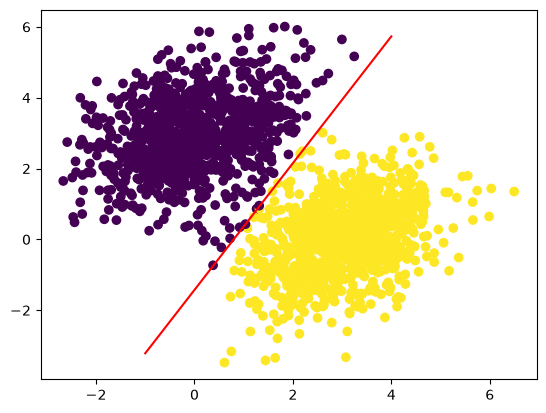

In [178]:
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()